# Прогноз количества запросов на следующий час

Ноутбук оставляет только основной пайплайн: подготовка почасового ряда, признаки, модели `baseline`, `linear`, `rf`, `cat`, `arima`, таблицу метрик и два финальных графика.


In [20]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from catboost import CatBoostRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["axes.grid"] = True


## Настройки


In [21]:
DATA_PATH = "df_with_cat.csv"
CITY_NAME = "İstanbul"

TEST_SIZE = 0.20
VALID_SIZE = 0.20
RANDOM_STATE = 42

RF_TREES = 500
CAT_ITERATIONS = 3000


## Подготовка данных


In [24]:
from sklearn.preprocessing import OneHotEncoder

events = pd.read_csv(DATA_PATH)

events["model_response_timestamp"] = pd.to_datetime(
    events["model_response_timestamp"],
    unit="s",
)
events["date_hour"] = events["model_response_timestamp"].dt.floor("h")

events["category"] = events["category"].fillna("unknown").astype(str)

hourly = (
    events.groupby(["name", "category", "date_hour"])
    .size()
    .reset_index(name="count")
)

city_hourly = hourly.loc[
    hourly["name"] == CITY_NAME,
    ["date_hour", "category", "count"],
]

all_hours = pd.date_range(
    city_hourly["date_hour"].min(),
    city_hourly["date_hour"].max(),
    freq="h",
)

all_categories = sorted(city_hourly["category"].unique())

full_index = pd.MultiIndex.from_product(
    [all_hours, all_categories],
    names=["date_hour", "category"],
)

base_df = (
    city_hourly.set_index(["date_hour", "category"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

base_df.insert(0, "name", CITY_NAME)
base_df = base_df.sort_values(["date_hour", "category"]).reset_index(drop=True)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

category_ohe = encoder.fit_transform(base_df[["category"]])

category_ohe_df = pd.DataFrame(
    category_ohe,
    columns=encoder.get_feature_names_out(["category"]),
    index=base_df.index,
)

base_df = pd.concat([base_df, category_ohe_df], axis=1)

base_df.head()

,name,date_hour,category,count,category_Agriculture,"category_Automotive, motorcycles and vehicles","category_Beauty, personal care and wellness","category_Construction, renovation and interior","category_Culture, arts and entertainment",category_Education and training,...,"category_Manufacturing, industry and equipment","category_Nature, parks and outdoor places",category_Other and unspecified,category_Real estate and business properties,category_Religion and community organizations,category_Retail and trade,category_Sports and active recreation,"category_Tourism, lodging and travel",category_Transportation and logistics,"category_Utilities, security and maintenance services"
0,İstanbul,2026-02-13 21:00:00,Agriculture,1,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,İstanbul,2026-02-13 21:00:00,"Automotive, motorcycles and vehicles",4,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,İstanbul,2026-02-13 21:00:00,"Beauty, personal care and wellness",1,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,İstanbul,2026-02-13 21:00:00,"Construction, renovation and interior",0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,İstanbul,2026-02-13 21:00:00,"Culture, arts and entertainment",2,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
base_df["count"].sum()

np.int64(17238)

In [29]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.sort_values(["category", "date_hour"]).reset_index(drop=True).copy()

    result["hour"] = result["date_hour"].dt.hour
    result["day"] = result["date_hour"].dt.day
    result["month"] = result["date_hour"].dt.month
    result["day_of_week"] = result["date_hour"].dt.dayofweek
    result["is_weekend"] = result["day_of_week"].isin([5, 6]).astype(int)

    result["hour_sin"] = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"] = np.cos(2 * np.pi * result["hour"] / 24)

    for day in range(7):
        result[f"day_of_week_{day}"] = (result["day_of_week"] == day).astype(int)

    return result


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.sort_values(["category", "date_hour"]).reset_index(drop=True).copy()

    group = result.groupby("category")["count"]

    result["lag_1"] = group.shift(1)
    result["lag_2"] = group.shift(2)
    result["lag_24"] = group.shift(24)

    result["rolling_mean_3"] = group.transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    result["rolling_mean_6"] = group.transform(
        lambda x: x.shift(1).rolling(6).mean()
    )
    result["rolling_mean_24"] = group.transform(
        lambda x: x.shift(1).rolling(24).mean()
    )

    return result


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    return add_lag_features(add_time_features(df))

In [30]:
base_df = base_df.sort_values(["category", "date_hour"]).reset_index(drop=True)

featured_df = build_features(base_df)

featured_df["predict_1h"] = (
    featured_df.groupby("category")["count"].shift(-1)
)
featured_df["target_hour"] = featured_df["date_hour"] + pd.Timedelta(hours=1)

excluded_dates = featured_df["month"].eq(2) & featured_df["day"].isin([14, 15, 25])

base_excluded_dates = (
    base_df["date_hour"].dt.month.eq(2)
    & base_df["date_hour"].dt.day.isin([14, 15, 25])
)

recursive_base_df = base_df.loc[~base_excluded_dates].reset_index(drop=True)
featured_df = featured_df.loc[~excluded_dates].reset_index(drop=True)

day_columns = [f"day_of_week_{day}" for day in range(7)]
category_columns = [
    col for col in featured_df.columns
    if col.startswith("category_")
]

feature_cols = [
    "count",
    "hour_sin",
    "hour_cos",
    "lag_1",
    "lag_2",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "is_weekend",
    *day_columns,
    *category_columns,
]

model_df = featured_df.dropna(subset=feature_cols + ["predict_1h"]).reset_index(drop=True)

model_df[["date_hour", "target_hour", "category", "count", "predict_1h"]].head()

,date_hour,target_hour,category,count,predict_1h
0,2026-02-16 00:00:00,2026-02-16 01:00:00,Agriculture,0,0.0
1,2026-02-16 01:00:00,2026-02-16 02:00:00,Agriculture,0,0.0
2,2026-02-16 02:00:00,2026-02-16 03:00:00,Agriculture,0,0.0
3,2026-02-16 03:00:00,2026-02-16 04:00:00,Agriculture,0,0.0
4,2026-02-16 04:00:00,2026-02-16 05:00:00,Agriculture,0,0.0


In [32]:
model_df["count"].sum()

np.int64(14872)

## Разделение на train / validation / test


In [34]:
split_index = int(len(model_df) * (1 - TEST_SIZE))
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

valid_index = int(len(train_df) * (1 - VALID_SIZE))
cat_train_df = train_df.iloc[:valid_index].copy()
cat_valid_df = train_df.iloc[valid_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df["predict_1h"]

X_cat_train = cat_train_df[feature_cols]
y_cat_train = cat_train_df["predict_1h"]
X_cat_valid = cat_valid_df[feature_cols]
y_cat_valid = cat_valid_df["predict_1h"]

X_test = test_df[feature_cols]
y_test = test_df["predict_1h"]

print(f"train: {X_train.shape}")
print(f"cat validation: {X_cat_valid.shape}")
print(f"test: {X_test.shape}")


train: (12179, 39)
cat validation: (2436, 39)
test: (3045, 39)


## Метрики


In [35]:
scores = []
preds_df = pd.DataFrame({
    "date_hour": test_df["target_hour"].values,
    "true": y_test.values,
})


def save_prediction(name: str, y_true, y_pred) -> None:
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    preds_df[name] = y_pred

    scores.append({
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    })


## Baseline

Наивный прогноз: считаем, что в следующий час будет столько же запросов, сколько в текущий.


In [36]:
y_pred_baseline = X_test["count"].values
save_prediction("baseline", y_test, y_pred_baseline)


## Linear Regression


In [37]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
save_prediction("linear", y_test, y_pred_linear)


## Random Forest


In [38]:
rf_model = RandomForestRegressor(
    n_estimators=RF_TREES,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
save_prediction("rf", y_test, y_pred_rf)


## CatBoost


In [42]:
cat_model = CatBoostRegressor(
    iterations=CAT_ITERATIONS,
    learning_rate=0.01,
    depth=8,
    l2_leaf_reg=3,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    early_stopping_rounds=100,
    verbose=200,
)
cat_model.fit(
    X_cat_train,
    y_cat_train,
    eval_set=(X_cat_valid, y_cat_valid),
    use_best_model=True,
)

y_pred_cat = cat_model.predict(X_test)
save_prediction("cat", y_test, y_pred_cat)


0:	learn: 11.8039468	test: 12.3181627	best: 12.3181627 (0)	total: 6.17ms	remaining: 18.5s
200:	learn: 6.7131804	test: 8.1395076	best: 8.1395076 (200)	total: 689ms	remaining: 9.6s
400:	learn: 5.5153108	test: 7.8058269	best: 7.8051014 (399)	total: 1.34s	remaining: 8.71s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 7.779669844
bestIteration = 490

Shrink model to first 491 iterations.


## ARIMA / SARIMAX

SARIMAX обучается на почасовом ряде и делает one-step прогноз: сначала добавляем фактическое значение текущего часа, затем прогнозируем следующий час.


In [18]:
train_series = train_df.set_index("date_hour")["count"].asfreq("h")

arima_model = SARIMAX(
    train_series,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_result = arima_model.fit(disp=False)

arima_work = arima_result
y_pred_arima = []

for date_hour, count in test_df[["date_hour", "count"]].itertuples(index=False, name=None):
    current_value = pd.Series(
        [count],
        index=pd.DatetimeIndex([date_hour]),
        name="count",
    )
    arima_work = arima_work.append(current_value, refit=False)
    y_pred_arima.append(float(arima_work.forecast(1).iloc[0]))

save_prediction("arima", y_test, y_pred_arima)


## Сводная таблица


In [39]:
scores_df = pd.DataFrame(scores).sort_values("RMSE").reset_index(drop=True)
display(scores_df)


,model,MAE,RMSE,R2,MAPE
0,rf,6.686840e-01,9.665076e-01,1.314958e-01,1.480487e+15
1,baseline,7.474548e-01,1.332183e+00,-6.500209e-01,1.337029e+15
2,linear,1.698745e+11,1.781718e+11,-2.951476e+22,5.237586e+26


## График с предсказаниями


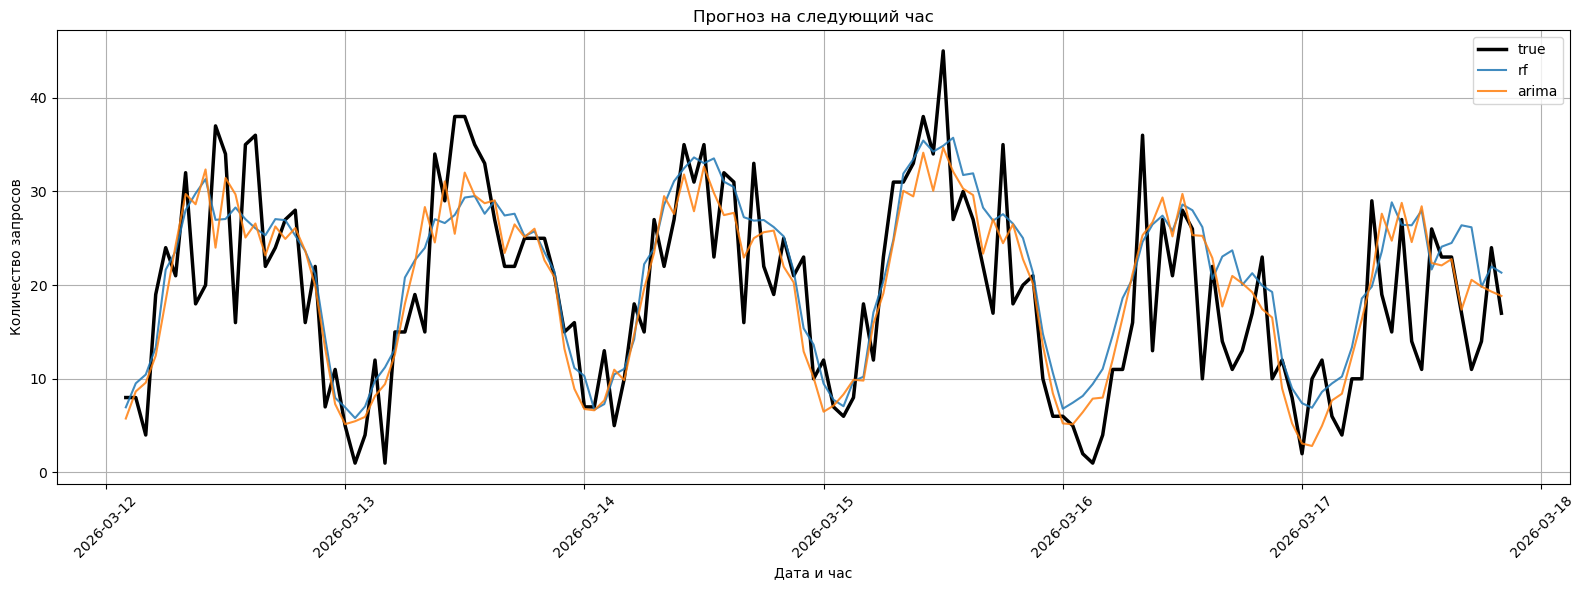

In [45]:
plot_part = preds_df.tail(24 * 7)

plt.figure(figsize=(16, 6))
plt.plot(plot_part["date_hour"], plot_part["true"], label="true", linewidth=2.5, color="black")

for model_name in ["rf", "arima"]:
    plt.plot(plot_part["date_hour"], plot_part[model_name], label=model_name, alpha=0.85)

plt.title("Прогноз на следующий час")
plt.xlabel("Дата и час")
plt.ylabel("Количество запросов")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Рекурсивный прогноз

Рекурсивный режим использует собственные предсказания как вход для следующих часов. Это показывает, как ошибка накапливается при прогнозе на горизонт больше одного часа.


In [50]:
RECURSIVE_MODEL = "linear"  # варианты: "linear", "rf", "cat", "arima"
RECURSIVE_HOURS = 140

recursive start: 2026-03-12 01:00:00
recursive hours: 139


,model,MAE,RMSE,R2,MAPE
0,linear_recursive,6.340267,7.839941,0.397391,0.727158


,date_hour,true,pred
0,2026-03-12 01:00:00,6.0,7.055889
1,2026-03-12 02:00:00,8.0,7.024558
2,2026-03-12 03:00:00,8.0,10.022940
3,2026-03-12 04:00:00,4.0,12.564997
4,2026-03-12 05:00:00,19.0,15.877057
...,...,...,...
134,2026-03-17 15:00:00,23.0,32.739414
135,2026-03-17 16:00:00,17.0,30.801516
136,2026-03-17 17:00:00,11.0,28.286138
137,2026-03-17 18:00:00,14.0,25.363773


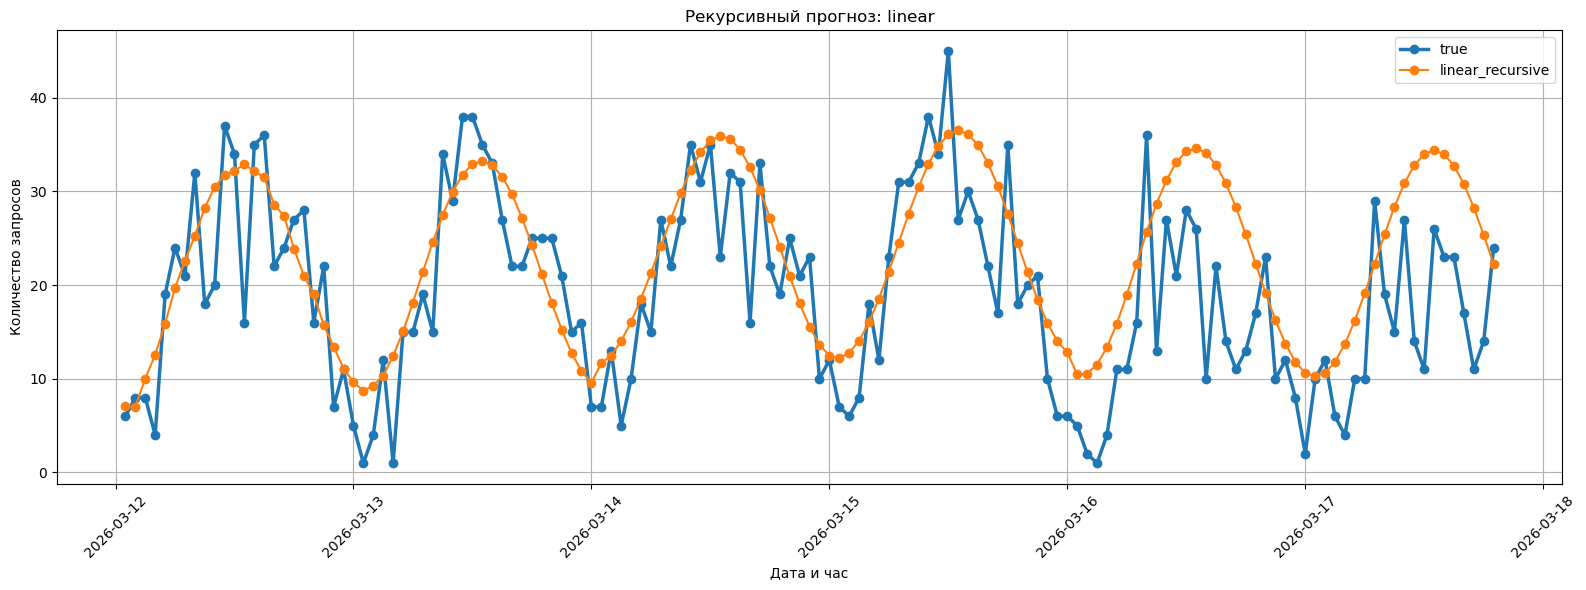

In [51]:
def choose_recursive_times(test_data: pd.DataFrame, hours: int) -> pd.DatetimeIndex:
    test_part = test_data.copy()
    test_part["test_date"] = test_part["date_hour"].dt.date

    date_counts = test_part["test_date"].value_counts().sort_index()
    full_dates = date_counts[date_counts >= 20]
    test_date = full_dates.index[0] if len(full_dates) else date_counts.index[0]

    start_time = pd.Timestamp(test_date)
    end_by_hours = start_time + pd.Timedelta(hours=hours - 1)
    end_of_test_date = start_time + pd.Timedelta(days=1) - pd.Timedelta(hours=1)
    end_time = max(end_by_hours, end_of_test_date)

    test_hours = set(test_part["date_hour"])
    target_times = pd.date_range(start_time, end_time, freq="h")
    return pd.DatetimeIndex([time for time in target_times if time in test_hours])


def predict_ml_recursive(model, target_times: pd.DatetimeIndex) -> pd.DataFrame:
    work_df = recursive_base_df.copy()
    rows = []

    for target_time in target_times:
        current_time = target_time - pd.Timedelta(hours=1)
        features_df = build_features(work_df)
        x_row = features_df.loc[features_df["date_hour"] == current_time, feature_cols]

        pred = float(model.predict(x_row)[0])
        pred = max(pred, 0)
        true_value = float(recursive_base_df.loc[recursive_base_df["date_hour"] == target_time, "count"].iloc[0])

        rows.append({"date_hour": target_time, "true": true_value, "pred": pred})
        work_df.loc[work_df["date_hour"] == target_time, "count"] = pred

    return pd.DataFrame(rows)


def predict_arima_recursive(target_times: pd.DatetimeIndex) -> pd.DataFrame:
    first_time = target_times[0]
    train_series = (
        recursive_base_df.loc[recursive_base_df["date_hour"] < first_time]
        .set_index("date_hour")["count"]
        .asfreq("h")
    )

    model = SARIMAX(
        train_series,
        order=(2, 0, 2),
        seasonal_order=(1, 0, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    work_model = model.fit(disp=False)
    rows = []

    for target_time in target_times:
        pred = max(float(work_model.forecast(1).iloc[0]), 0)
        true_value = float(recursive_base_df.loc[recursive_base_df["date_hour"] == target_time, "count"].iloc[0])
        rows.append({"date_hour": target_time, "true": true_value, "pred": pred})

        predicted_value = pd.Series(
            [pred],
            index=pd.DatetimeIndex([target_time]),
            name="count",
        )
        work_model = work_model.append(predicted_value, refit=False)

    return pd.DataFrame(rows)


recursive_models = {
    "linear": linear_model,
    "rf": rf_model,
    "cat": cat_model,
}

target_times = choose_recursive_times(test_df, RECURSIVE_HOURS)
print("recursive start:", target_times[0])
print("recursive hours:", len(target_times))

if RECURSIVE_MODEL == "arima":
    recursive_df = predict_arima_recursive(target_times)
else:
    recursive_df = predict_ml_recursive(recursive_models[RECURSIVE_MODEL], target_times)

recursive_score = {
    "model": f"{RECURSIVE_MODEL}_recursive",
    "MAE": mean_absolute_error(recursive_df["true"], recursive_df["pred"]),
    "RMSE": np.sqrt(mean_squared_error(recursive_df["true"], recursive_df["pred"])),
    "R2": r2_score(recursive_df["true"], recursive_df["pred"]),
    "MAPE": mean_absolute_percentage_error(recursive_df["true"], recursive_df["pred"]),
}

display(pd.DataFrame([recursive_score]))
display(recursive_df)

plt.figure(figsize=(16, 6))
plt.plot(recursive_df["date_hour"], recursive_df["true"], marker="o", label="true", linewidth=2.5)
plt.plot(
    recursive_df["date_hour"],
    recursive_df["pred"],
    marker="o",
    label=f"{RECURSIVE_MODEL}_recursive",
)

plt.title(f"Рекурсивный прогноз: {RECURSIVE_MODEL}")
plt.xlabel("Дата и час")
plt.ylabel("Количество запросов")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import joblib
joblib.dump(linear_model, "linear_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(cat_model, "cat_model.pkl")
joblib.dump(arima_result, "arima_model.pkl")

AttributeError: module 'joblib' has no attribute 'save'